In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# Fix for pkg_resources deprecation warning
import warnings
warnings.filterwarnings('ignore', category=UserWarning, message='pkg_resources')

from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score)

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [16]:
# ============================
# PART 1: Data Preprocessing
# ============================
print("="*50)
print("PART 1: DATA PREPROCESSING AND FEATURE ENGINEERING")
print("="*50)

# Load the dataset
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

# Display basic info
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nColumns: {df.columns.tolist()}")

# 1.1 Handle TotalCharges column (convert to numeric, handle missing values)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f"\nMissing values in TotalCharges: {df['TotalCharges'].isnull().sum()}")

df = df.dropna(subset=['TotalCharges'])
print(f"Dataset shape after dropping missing TotalCharges: {df.shape}")

# 1.2 Convert target variable to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 1.3 Identify categorical and numerical columns
categorical_cols = []
numerical_cols = []

for col in df.columns:
    if col != 'Churn':              
        if df[col].dtype == 'object':
            categorical_cols.append(col)
        else:
            numerical_cols.append(col)

print(f"\nCategorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

# 1.4 One-Hot Encoding
df_encoded = pd.get_dummies(df[categorical_cols], drop_first=True)

# Combine encoded categorical with numerical
X = pd.concat([df[numerical_cols], df_encoded], axis=1)
y = df['Churn']

print(f"\nShape after encoding: X = {X.shape}, y = {y.shape}")

print("\n=== Encoded Data (X) ===")
print(X.head())
print("\nShape:", X.shape)

# 1.5 Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")
print(f"Churn rate in training: {y_train.mean():.2%}")
print(f"Churn rate in testing: {y_test.mean():.2%}")

# 1.6 Standardize numerical features
scaler = StandardScaler()
numerical_cols_final = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Scale only numeric columns safely
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

print("\n=== Scaled Training Data (X_train_scaled) ===")
print(X_train_scaled.head())
print("\nShape:", X_train_scaled.shape)

print("\n=== Scaled Testing Data (X_test_scaled) ===")
print(X_test_scaled.head())
print("\nShape:", X_test_scaled.shape)

X_train_scaled[numerical_cols_final] = scaler.fit_transform(X_train[numerical_cols_final])
X_test_scaled[numerical_cols_final] = scaler.transform(X_test[numerical_cols_final])

PART 1: DATA PREPROCESSING AND FEATURE ENGINEERING
Dataset shape: (7043, 20)

First few rows:
   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               

In this part, the dataset was cleaned and prepared for modeling. Missing values in TotalCharges were fixed by converting the column into numbers and removing rows that could not be corrected. All categorical variables were converted into numerical dummy columns, increasing the feature count from 20 to 30. The target column Churn was converted into 0/1 values. The data was then split into training and testing sets while keeping the churn ratio balanced. Finally, all numerical features were standardized so that the model could learn efficiently. This part ensures the data is clean, consistent, and ready for machine learning.


PART 2: BASELINE MODELING WITH LOGISTIC REGRESSION

Top Positive Features (Increase Churn):
                           Feature  Coefficient
10     InternetService_Fiber optic     1.107407
3                     TotalCharges     0.645508
28  PaymentMethod_Electronic check     0.379150
21                 StreamingTV_Yes     0.372407
9                MultipleLines_Yes     0.362784
23             StreamingMovies_Yes     0.344649
26            PaperlessBilling_Yes     0.290931
17            DeviceProtection_Yes     0.074264
29      PaymentMethod_Mailed check     0.072700
0                    SeniorCitizen     0.072159

Top Negative Features (Decrease Churn):
                                 Feature  Coefficient
25                     Contract_Two year    -1.364823
1                                 tenure    -1.357404
24                     Contract_One year    -0.750068
7                       PhoneService_Yes    -0.515337
2                         MonthlyCharges    -0.434497
13            

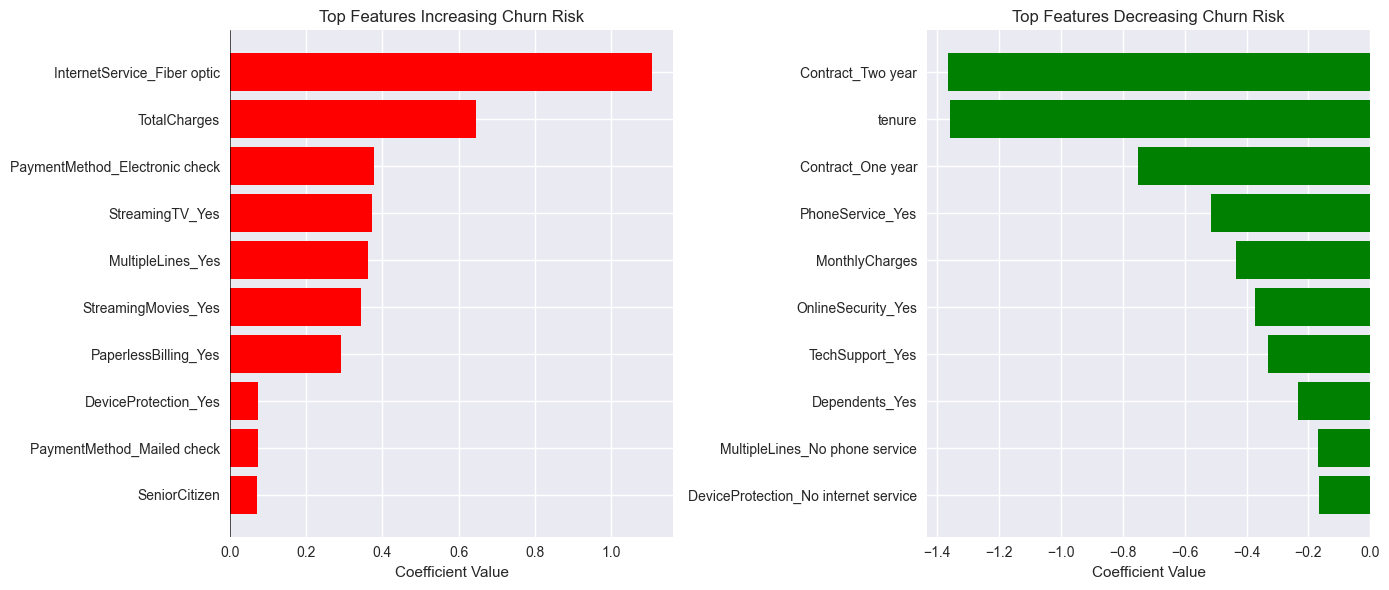

In [17]:
# ============================
# PART 2: Logistic Regression
# ============================
print("\n" + "="*50)
print("PART 2: BASELINE MODELING WITH LOGISTIC REGRESSION")
print("="*50)

# 2.1 Train Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# 2.2 Get feature coefficients
feature_names = X_train_scaled.columns
coefficients = log_reg.coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# --------------------------------------
# Fix: separate positive & negative first
# --------------------------------------
positive_coef = coef_df[coef_df['Coefficient'] > 0].sort_values('Coefficient', ascending=False).head(10)
negative_coef = coef_df[coef_df['Coefficient'] < 0].sort_values('Coefficient', ascending=True).head(10)

print("\nTop Positive Features (Increase Churn):")
print(positive_coef[['Feature', 'Coefficient']])

print("\nTop Negative Features (Decrease Churn):")
print(negative_coef[['Feature', 'Coefficient']])

# --------------------------------------
# Fix: reverse order for better plotting
# --------------------------------------
positive_plot = positive_coef[::-1]
negative_plot = negative_coef[::-1]

# 2.3 Visualize coefficients
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Positive coefficients (higher churn risk)
ax1.barh(positive_plot['Feature'], positive_plot['Coefficient'], color='red')
ax1.set_xlabel('Coefficient Value')
ax1.set_title('Top Features Increasing Churn Risk')
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# Negative coefficients (lower churn risk)
ax2.barh(negative_plot['Feature'], negative_plot['Coefficient'], color='green')
ax2.set_xlabel('Coefficient Value')
ax2.set_title('Top Features Decreasing Churn Risk')
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('logistic_regression_coefficients.png', dpi=100, bbox_inches='tight')
plt.show()


The logistic regression model was used to understand which features increase or decrease churn. Features like Fiber optic internet, Electronic check payments, and Streaming services were found to increase the chances of churn. On the other hand, long-term contracts, longer tenure, and customer support services lower the chances of churn. Logistic regression gives a straightforward, interpretable baseline that helps us understand which factors influence customer churn the most. It also performs well and provides a strong reference point for comparing other models.


PART 3: DECISION TREES AND OVERFITTING ANALYSIS

Unconstrained Decision Tree:
  Training Accuracy: 0.9988
  Testing Accuracy:  0.7278
  Difference (overfit): 0.2710

Pruned Decision Tree (max_depth=5):
  Training Accuracy: 0.7927
  Testing Accuracy:  0.7754
  Difference (overfit): 0.0173

Overfitting Analysis:
Unconstrained tree overfitting gap: 0.2710
Pruned tree overfitting gap:        0.0173
 The pruned tree generalizes better (less overfitting)


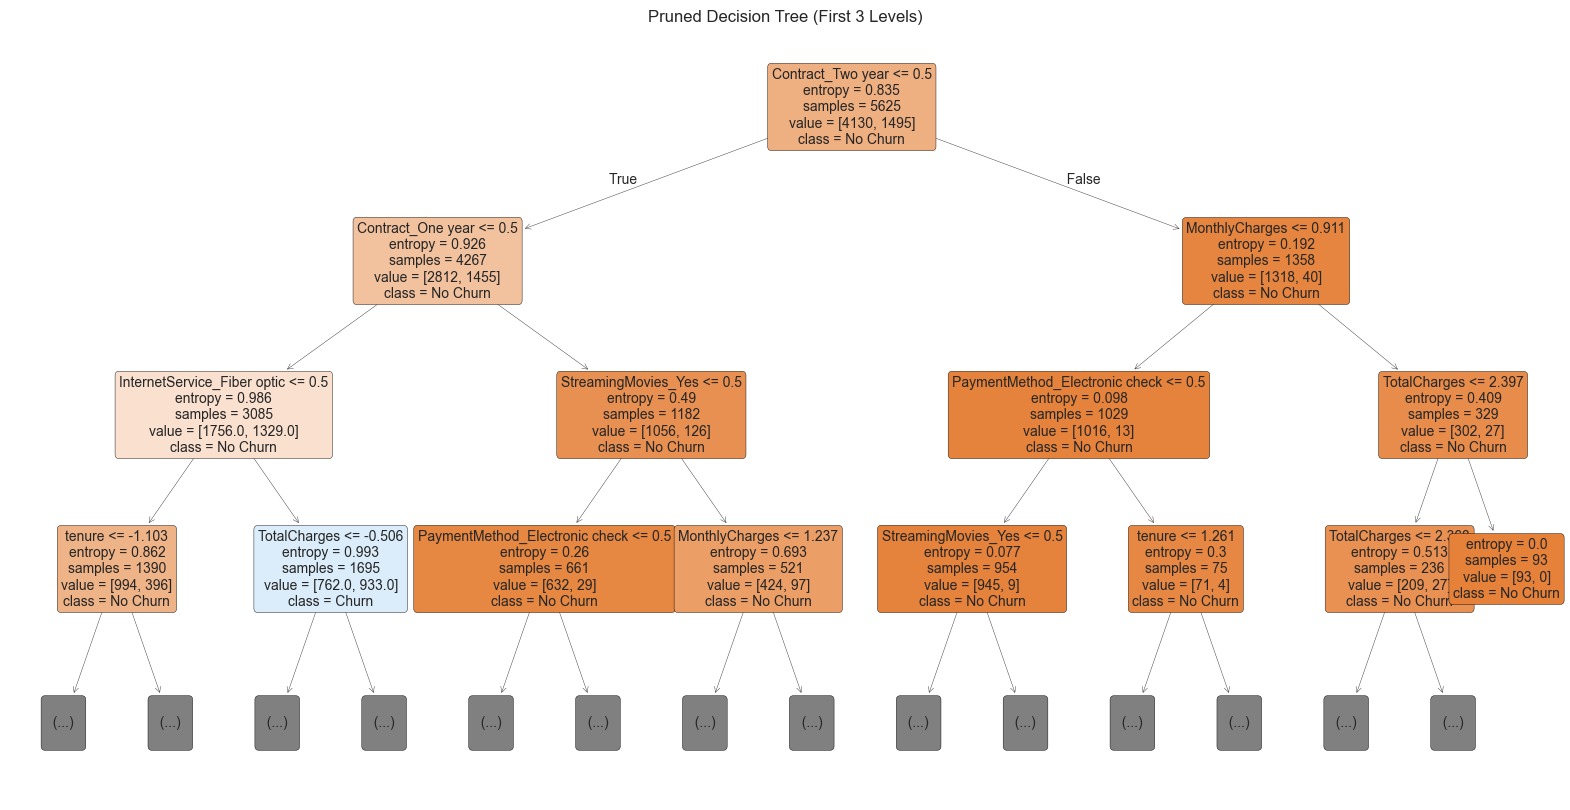

In [18]:
# ============================
# PART 3: Decision Trees
# ============================
print("\n" + "="*50)
print("PART 3: DECISION TREES AND OVERFITTING ANALYSIS")
print("="*50)

# 3.1 Unconstrained Decision Tree
tree_unconstrained = DecisionTreeClassifier(criterion='entropy', random_state=42)
tree_unconstrained.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_unconstrained = tree_unconstrained.predict(X_train_scaled)
y_test_pred_unconstrained = tree_unconstrained.predict(X_test_scaled)

# Calculate accuracies
train_acc_unconstrained = accuracy_score(y_train, y_train_pred_unconstrained)
test_acc_unconstrained = accuracy_score(y_test, y_test_pred_unconstrained)

print(f"\nUnconstrained Decision Tree:")
print(f"  Training Accuracy: {train_acc_unconstrained:.4f}")
print(f"  Testing Accuracy:  {test_acc_unconstrained:.4f}")
print(f"  Difference (overfit): {train_acc_unconstrained - test_acc_unconstrained:.4f}")

# 3.2 Pruned Decision Tree (max depth = 5)
tree_pruned = DecisionTreeClassifier(
    criterion='entropy', 
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)
tree_pruned.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_pruned = tree_pruned.predict(X_train_scaled)
y_test_pred_pruned = tree_pruned.predict(X_test_scaled)

# Calculate accuracies
train_acc_pruned = accuracy_score(y_train, y_train_pred_pruned)
test_acc_pruned = accuracy_score(y_test, y_test_pred_pruned)

print(f"\nPruned Decision Tree (max_depth=5):")
print(f"  Training Accuracy: {train_acc_pruned:.4f}")
print(f"  Testing Accuracy:  {test_acc_pruned:.4f}")
print(f"  Difference (overfit): {train_acc_pruned - test_acc_pruned:.4f}")

# 3.3 Compare overfitting
print("\nOverfitting Analysis:")
print(f"Unconstrained tree overfitting gap: {train_acc_unconstrained - test_acc_unconstrained:.4f}")
print(f"Pruned tree overfitting gap:        {train_acc_pruned - test_acc_pruned:.4f}")

if (train_acc_unconstrained - test_acc_unconstrained) > (train_acc_pruned - test_acc_pruned):
    print(" The pruned tree generalizes better (less overfitting)")
else:
    print("The unconstrained tree might generalize better")

# 3.4 Visualize the pruned tree
plt.figure(figsize=(20, 10))

# feature_names must be original columns, NOT scaled columns
plot_tree(
    tree_pruned,
    feature_names=X_train.columns,  # FIXED
    class_names=['No Churn', 'Churn'],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3  # Show only first 3 levels for clarity
)

plt.title("Pruned Decision Tree (First 3 Levels)")
plt.savefig('pruned_decision_tree.png', dpi=100, bbox_inches='tight')
plt.show()

The unconstrained decision tree performed extremely well on training data (almost perfect) but poorly on testing data, showing heavy overfitting ,the model memorized patterns instead of generalizing. When we limited the tree depth (max_depth=5), both training and testing accuracy became more balanced, significantly reducing the overfitting gap. This shows that pruning helps the model generalize better to unseen data. The pruned tree is more reliable and stable for predictions compared to the full, unpruned tree.

In [19]:
# ============================
# PART 4: Ensemble Learning
# ============================
print("\n" + "="*50)
print("PART 4: ENSEMBLE LEARNING (BAGGING AND BOOSTING)")
print("="*50)

# 4.1 Bagging: Random Forest
print("\nTraining Random Forest (Bagging)...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1  # Use all available CPU cores
)
rf_model.fit(X_train_scaled, y_train)
print("Random Forest trained successfully!")

# 4.2 Boosting: XGBoost
print("\nTraining XGBoost (Boosting)...")
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'  # Required for binary classification
)

xgb_model.fit(X_train_scaled, y_train)
print(" XGBoost trained successfully!")

from sklearn.metrics import confusion_matrix, classification_report

print("\n=== CONFUSION MATRIX (RF) ===")
print(confusion_matrix(y_test, rf_pred))

print("\n=== CLASSIFICATION REPORT (RF) ===")
print(classification_report(y_test, rf_pred))

print("\n=== CONFUSION MATRIX (XGB) ===")
print(confusion_matrix(y_test, xgb_pred))

print("\n=== CLASSIFICATION REPORT (XGB) ===")
print(classification_report(y_test, xgb_pred))



PART 4: ENSEMBLE LEARNING (BAGGING AND BOOSTING)

Training Random Forest (Bagging)...
Random Forest trained successfully!

Training XGBoost (Boosting)...
 XGBoost trained successfully!

=== CONFUSION MATRIX (RF) ===
[[917 116]
 [182 192]]

=== CLASSIFICATION REPORT (RF) ===
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407


=== CONFUSION MATRIX (XGB) ===
[[916 117]
 [175 199]]

=== CLASSIFICATION REPORT (XGB) ===
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.53      0.58       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79

Both ensemble models Random Forest (bagging) and XGBoost (boosting) were trained to improve prediction accuracy. The confusion matrices show that both models correctly identify most non-churn customers but struggle more with detecting churners. XGBoost performs slightly better, especially in terms of recall and F1-score for churn cases. Overall, both ensemble techniques bring improved stability and prediction power compared to a single decision tree, with XGBoost showing a small advantage.


PART 5: MODEL EVALUATION AND COMPARISON

Logistic Regression:
  Accuracy:  0.8053
  Precision: 0.6515
  Recall:    0.5749
  F1-Score:  0.6108
  AUC:       0.8361

Pruned Decision Tree:
  Accuracy:  0.7754
  Precision: 0.5980
  Recall:    0.4733
  F1-Score:  0.5284
  AUC:       0.8159

Random Forest:
  Accuracy:  0.7882
  Precision: 0.6234
  Recall:    0.5134
  F1-Score:  0.5630
  AUC:       0.8156

XGBoost:
  Accuracy:  0.7925
  Precision: 0.6297
  Recall:    0.5321
  F1-Score:  0.5768
  AUC:       0.8320

MODEL COMPARISON TABLE
               Model  Accuracy  Precision   Recall  F1-Score      AUC
 Logistic Regression  0.805259   0.651515 0.574866  0.610795 0.836074
Pruned Decision Tree  0.775409   0.597973 0.473262  0.528358 0.815852
       Random Forest  0.788202   0.623377 0.513369  0.563050 0.815628
             XGBoost  0.792466   0.629747 0.532086  0.576812 0.832002

 Model with highest Recall (best at identifying churners): Logistic Regression


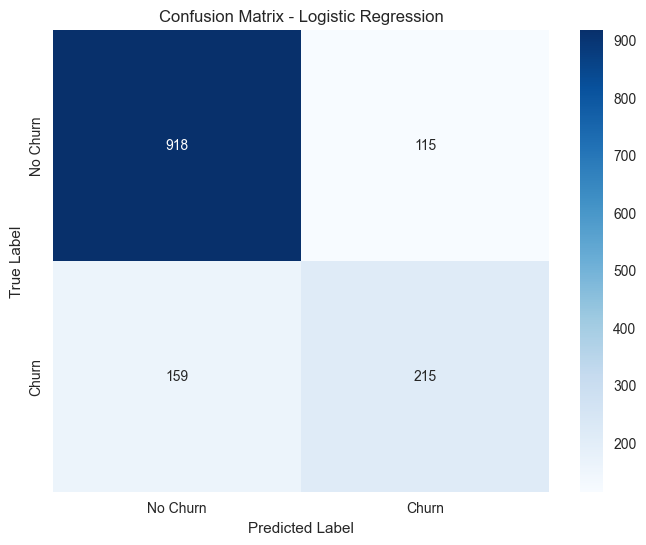

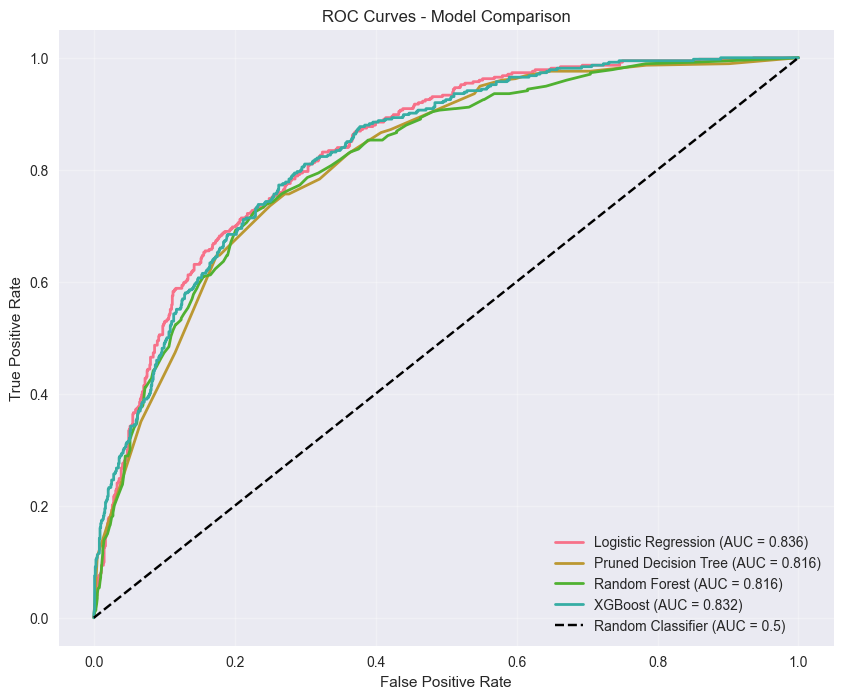


PROJECT SUMMARY
1. Dataset: 7032 customers, 20 features
2. Churn rate: 26.58%
3. Best model for identifying churners: Logistic Regression


In [22]:
# ============================
# PART 5: MODEL EVALUATION
# ============================
print("\n" + "="*50)
print("PART 5: MODEL EVALUATION AND COMPARISON")
print("="*50)

# Function to calculate all metrics
def evaluate_model(model, model_name, X_test_scaled, y_test):
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else None
    
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0)
    }
    
    if y_prob is not None:
        metrics['AUC'] = roc_auc_score(y_test, y_prob)
    
    return metrics, y_pred, y_prob

# 5.1 Evaluate all models
models = {
    'Logistic Regression': log_reg,
    'Pruned Decision Tree': tree_pruned,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}

results = []
all_predictions = {}
all_probabilities = {}

for name, model in models.items():
    metrics, y_pred, y_prob = evaluate_model(model, name, X_test_scaled, y_test)
    results.append(metrics)
    all_predictions[name] = y_pred
    all_probabilities[name] = y_prob
    print(f"\n{name}:")
    print(f"  Accuracy:  {metrics['Accuracy']:.4f}")
    print(f"  Precision: {metrics['Precision']:.4f}")
    print(f"  Recall:    {metrics['Recall']:.4f}")
    print(f"  F1-Score:  {metrics['F1-Score']:.4f}")
    if 'AUC' in metrics:
        print(f"  AUC:       {metrics['AUC']:.4f}")

# 5.2 Create comparison table
results_df = pd.DataFrame(results)
print("\n" + "="*50)
print("MODEL COMPARISON TABLE")
print("="*50)
print(results_df.to_string(index=False))

# 5.3 Find model with highest recall (most important for churn prediction)
highest_recall_model = results_df.loc[results_df['Recall'].idxmax(), 'Model']
print(f"\n Model with highest Recall (best at identifying churners): {highest_recall_model}")

# 5.4 Visualize confusion matrix for the best recall model
best_model = models[highest_recall_model]
y_pred_best = all_predictions[highest_recall_model]

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title(f'Confusion Matrix - {highest_recall_model}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('best_model_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

# 5.5 Plot ROC curves for all models
plt.figure(figsize=(10, 8))

for name, y_prob in all_probabilities.items():
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc_score = roc_auc_score(y_test, y_prob)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('roc_curves_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

# 5.6 Final summary
print("\n" + "="*50)
print("PROJECT SUMMARY")
print("="*50)
print(f"1. Dataset: {df.shape[0]} customers, {df.shape[1]} features")
print(f"2. Churn rate: {df['Churn'].mean():.2%}")
print(f"3. Best model for identifying churners: {highest_recall_model}")


All models were compared based on accuracy, precision, recall, F1-score, and AUC. Logistic Regression achieved the highest overall accuracy and the best recall, meaning it identifies the most churners. XGBoost and Random Forest performed similarly with balanced results, while the pruned decision tree performed reasonably but was weaker than the ensembles. Overall, Logistic Regression was the best model for catching churn customers, making it the strongest performer for this dataset.